In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from datetime import date
from sklearn.metrics import root_mean_squared_error, r2_score

from aquacrop import AquaCrop, Crop, Soil, Weather

from aquacrop_slovenia import config
from aquacrop_slovenia.plots import plot_yield_timeseries_comparison, plot_yield_scatter, plot_gdd_and_yield, \
    plot_yield_timeseries_residuals
from aquacrop_slovenia.reading_data import get_yield, get_yield_for_comparison, get_co2_for_aquacrop, get_station_weather
from aquacrop_slovenia.parameter_defaults_jablje import jablje_soil_layers, jablje_curve_number, \
    jablje_readily_evaporable_water, jablje_maize_params, jablje_optimal_management, jablje_initial_cond, \
    jablje_groundwater
from aquacrop_slovenia.diagnostics import nse, kge, mkge

Loaded data sizes: Temperatures=1096, ETo=1096, Rain=1096


In [3]:
# Set up working directory for outputs
output_dir = config.RAMDISK_DIR / "testing_daily"
LOCATION = "jablje"

plant and end dates are set to be the same every year - TODO TEMPORARY!!!

We exclude 2017 since we dont have ET data for most of the year

In [4]:
year = 1993
simulation_periods = [
    {
        "start_date": date(year, 1, 1),
        "end_date": date(year, 10, 10),
        "planting_date": date(year, 5, 3),
        "is_seeding_year": True,
    }
]
#for year in range(1993, 2024) if year not in [2017]]

In [5]:
jablje_temperatures, jablje_eto, jablje_rain = load_station_weather(8) # Jablje uses ARSO meteo station 8 data

In [6]:
historical_co2 = get_co2_for_aquacrop("historical")

In [7]:
jablje_weather = Weather(
    location=LOCATION,
    temperatures=jablje_temperatures,
    eto_values=jablje_eto,
    rainfall_values=jablje_rain,
    record_type=1,
    first_day=1,
    first_month=1,
    first_year=1993,
    co2_records=historical_co2
)

In [8]:
jablje_maize = Crop(
    name=f"{LOCATION} maize",
    description=f"{LOCATION} maize uncalibrated",
    params=jablje_maize_params
)

In [9]:
jablje_soil = Soil(
    name=f"{LOCATION} soil",
    description=f"{LOCATION} silt loam soil uncalibrated",
    soil_layers=jablje_soil_layers,
    curve_number=jablje_curve_number,
    readily_evaporable_water=jablje_readily_evaporable_water
)

In [10]:
# Create AquaCrop simulation
simulation = AquaCrop(
    simulation_periods=simulation_periods,
    crop=jablje_maize,
    soil=jablje_soil,
    management=jablje_optimal_management,
    initial_conditions=jablje_initial_cond,
    climate=jablje_weather,
    ground_water=jablje_groundwater,
    working_dir=output_dir,
    need_daily_output=True,
    need_seasonal_output=True,
    need_harvest_output=False,
    need_evaluation_output=False
)

In [11]:
# Run the simulation
results = simulation.run()
seasonal_results = results["season"]

Setting up working directory at: E:\aquacrop\testing_daily
Running AquaCrop simulation with project file: E:\aquacrop\testing_daily\LIST\PROJECT.PRM
Detected platform: windows (AMD64)
Looking for executable at: C:\Users\rokku\Documents\Code\aquacrop-slovenia\.venv\Lib\site-packages\model\windows\aquacrop.exe
Using AquaCrop executable: E:\aquacrop\testing_daily\aquacrop.exe
AquaCrop simulation completed successfully
Parsing simulation results...
Results successfully parsed


In [12]:
results["day"]

,Day,Month,Year,DAP,Stage,WC(2.30),Rain,Irri,Surf,Infilt,...,9_1,ECe10,ECe11,ECe12,Rain_1,ETo,Tmin,Tavg,Tmax,CO2
0,1,1,1993,-9,0,807.2,0.0,0.0,0.0,0.0,...,None,None,None,None,None,None,None,None,None,None
1,2,1,1993,-9,0,814.2,0.0,0.0,0.0,0.0,...,None,None,None,None,None,None,None,None,None,None
2,3,1,1993,-9,0,817.8,0.0,0.0,0.0,0.0,...,None,None,None,None,None,None,None,None,None,None
3,4,1,1993,-9,0,819.2,0.0,0.0,0.0,0.0,...,None,None,None,None,None,None,None,None,None,None
4,5,1,1993,-9,0,819.7,0.0,0.0,0.0,0.0,...,None,None,None,None,None,None,None,None,None,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
278,6,10,1993,157,4,824.6,2.4,0.0,0.0,2.4,...,None,None,None,None,None,None,None,None,None,None
279,7,10,1993,158,4,844.9,47.0,0.0,0.0,22.5,...,None,None,None,None,None,None,None,None,None,None
280,8,10,1993,159,4,839.1,7.3,0.0,0.0,6.6,...,None,None,None,None,None,None,None,None,None,None
281,9,10,1993,160,4,845.0,26.0,0.0,0.0,16.6,...,None,None,None,None,None,None,None,None,None,None


<Axes: >

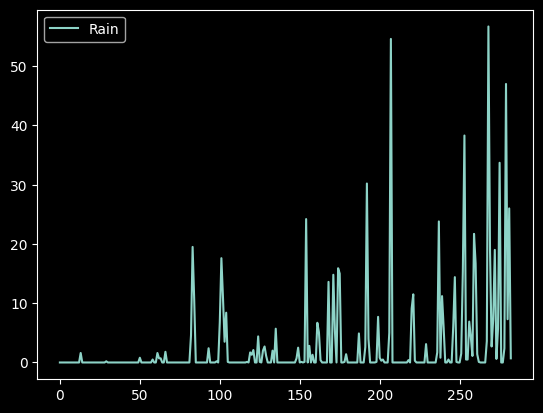

In [13]:
results["day"].plot(y="Rain")

<Axes: >

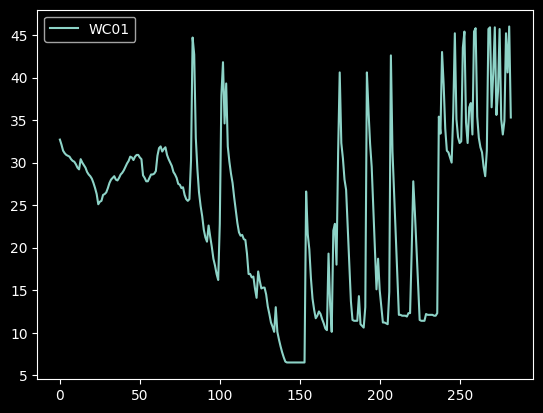

In [14]:
results["day"].plot(y="WC01")

<Axes: >

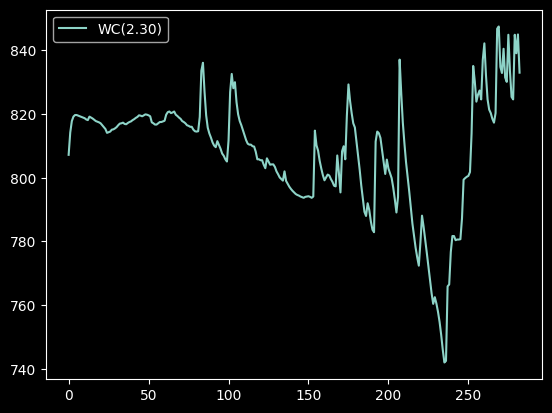

In [15]:
results["day"].plot(y="WC(2.30)")

<Axes: >

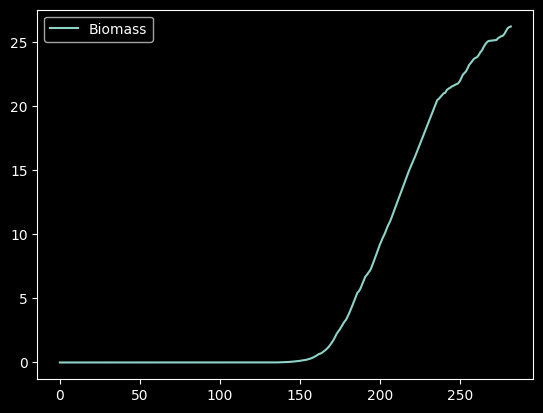

In [16]:
results["day"].plot(y="Biomass")

<Axes: >

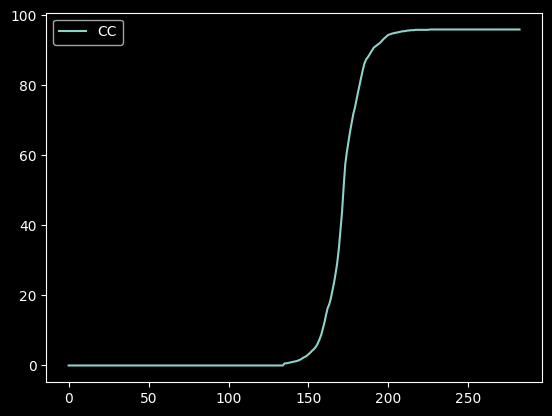

In [17]:
results["day"].plot(y="CC")

<Axes: >

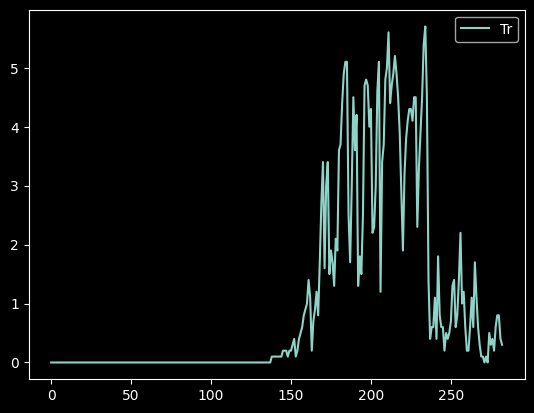

In [18]:
results["day"].plot(y="Tr")

<Axes: >

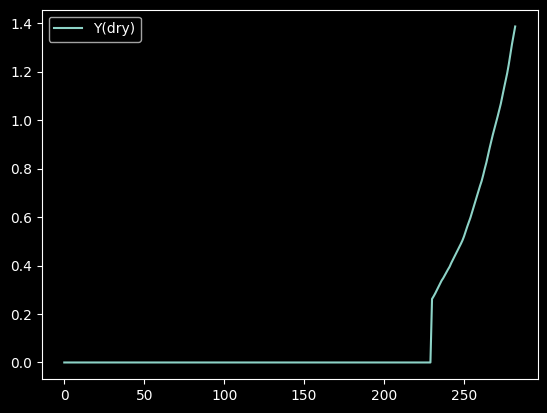

In [19]:
results["day"].plot(y="Y(dry)")

In [20]:
import contextlib
import copy
import io
import queue
from concurrent.futures import ThreadPoolExecutor, as_completed

import matplotlib.cm as cm
import numpy as np

In [21]:
gdd_sweep_params = {
    "gdd_emergence":        [40, 60, 80, 100, 120],          # default: 80
    "gdd_max_rooting":      [1100, 1250, 1409, 1550, 1700],  # default: 1409
    "gdd_senescence":       [1200, 1300, 1400, 1500, 1600],  # default: 1400
    "gdd_maturity":         [1500, 1600, 1700, 1800, 1900],  # default: 1700
    "gdd_cycle_length":     [1500, 1600, 1700, 1800, 1900],  # default: 1700
    "gdd_flowering":        [700, 800, 880, 950, 1050],      # default: 880
    "gdd_flowering_length": [120, 150, 180, 210, 240],       # default: 180
    "gdd_hi_start":         [600, 700, 750, 850, 950],       # default: 750
}

INTEGER_PARAMS = {name for name, val in jablje_maize_params.items() if isinstance(val, int)}

import os
MAX_WORKERS = os.cpu_count()
worker_dirs = []
for i in range(MAX_WORKERS):
    d = config.RAMDISK_DIR / f"daily_gdd_{i}"
    d.mkdir(parents=True, exist_ok=True)
    worker_dirs.append(d)

gdd_dir_queue = queue.Queue()
for d in worker_dirs:
    gdd_dir_queue.put(d)


def run_gdd_param(param_name, value):
    working_dir = gdd_dir_queue.get()
    try:
        params = copy.deepcopy(jablje_maize_params)
        params[param_name] = int(round(value)) if param_name in INTEGER_PARAMS else float(value)
        crop = Crop(name=f"{LOCATION} maize", description=f"{param_name}={value}", params=params)
        sim = AquaCrop(
            simulation_periods=simulation_periods,
            crop=crop,
            soil=jablje_soil,
            management=jablje_optimal_management,
            initial_conditions=jablje_initial_cond,
            climate=jablje_weather,
            ground_water=jablje_groundwater,
            working_dir=working_dir,
            need_daily_output=True,
            need_seasonal_output=False,
            need_harvest_output=False,
            need_evaluation_output=False,
        )
        with contextlib.redirect_stdout(io.StringIO()):
            res = sim.run()
        daily = res["day"]
        return param_name, value, daily[daily["DAP"] >= 0].copy()
    finally:
        gdd_dir_queue.put(working_dir)


gdd_daily_results = {name: {} for name in gdd_sweep_params}

tasks = [(name, val) for name, values in gdd_sweep_params.items() for val in values]
with ThreadPoolExecutor(max_workers=MAX_WORKERS) as executor:
    futures = [executor.submit(run_gdd_param, name, val) for name, val in tasks]
    for future in as_completed(futures):
        param_name, value, daily = future.result()
        gdd_daily_results[param_name][value] = daily

print("Done.")

AquaCrop simulation completed successfully
Parsing simulation results...
AquaCrop simulation completed successfully
Parsing simulation results...
AquaCrop simulation completed successfully
Parsing simulation results...
AquaCrop simulation completed successfully
Parsing simulation results...
AquaCrop simulation completed successfully
Parsing simulation results...
Results successfully parsed


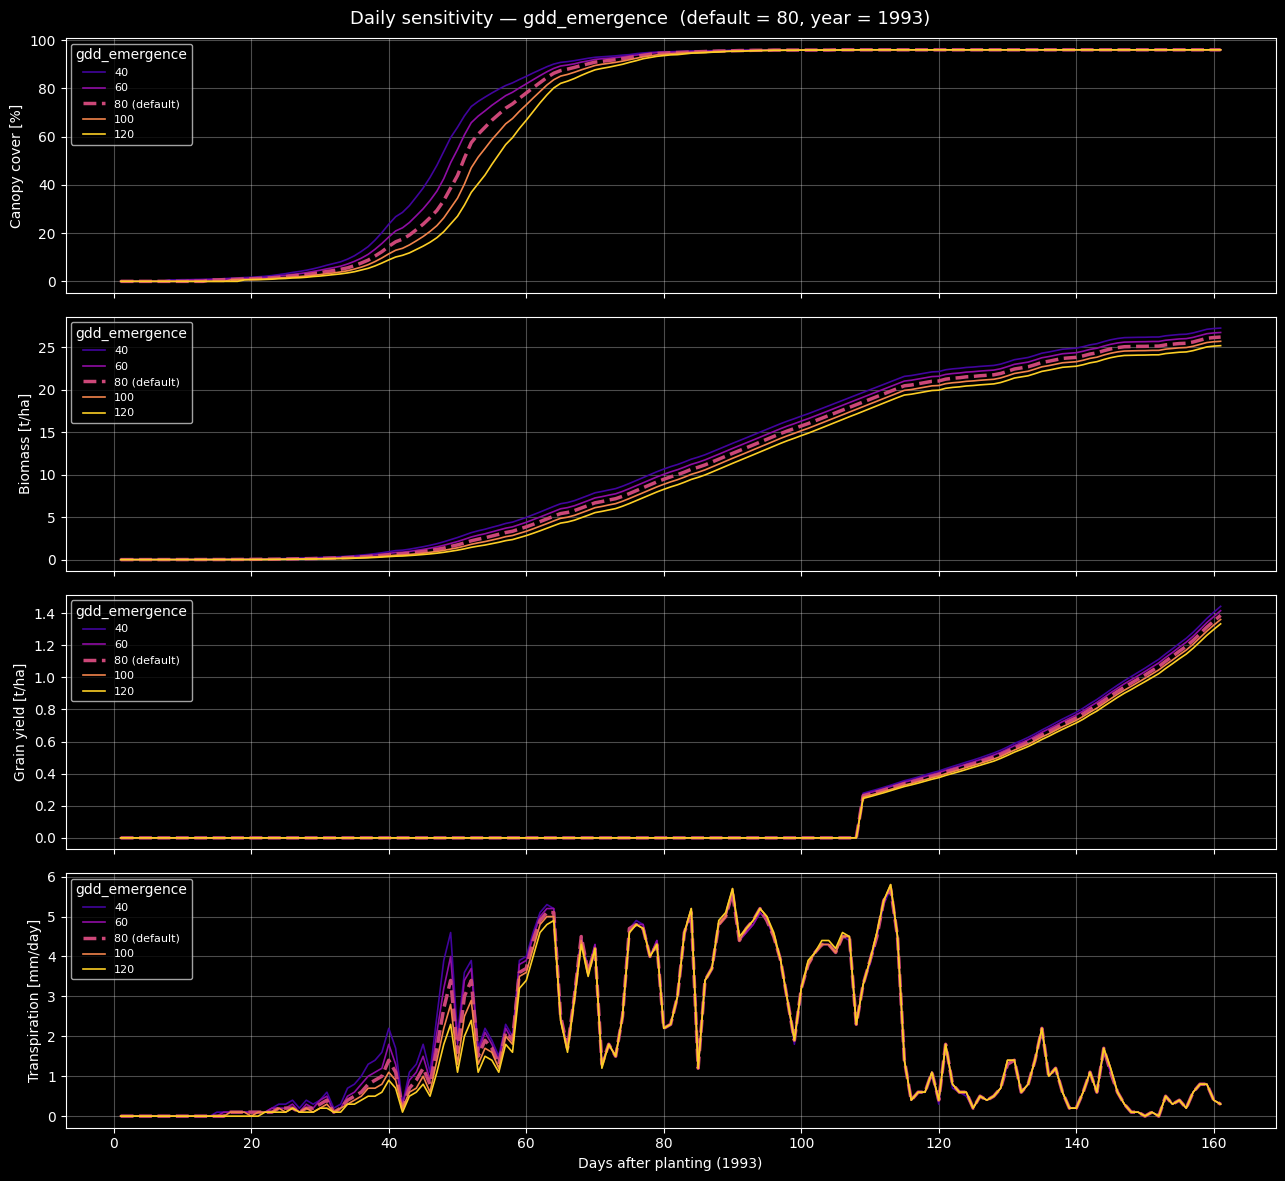

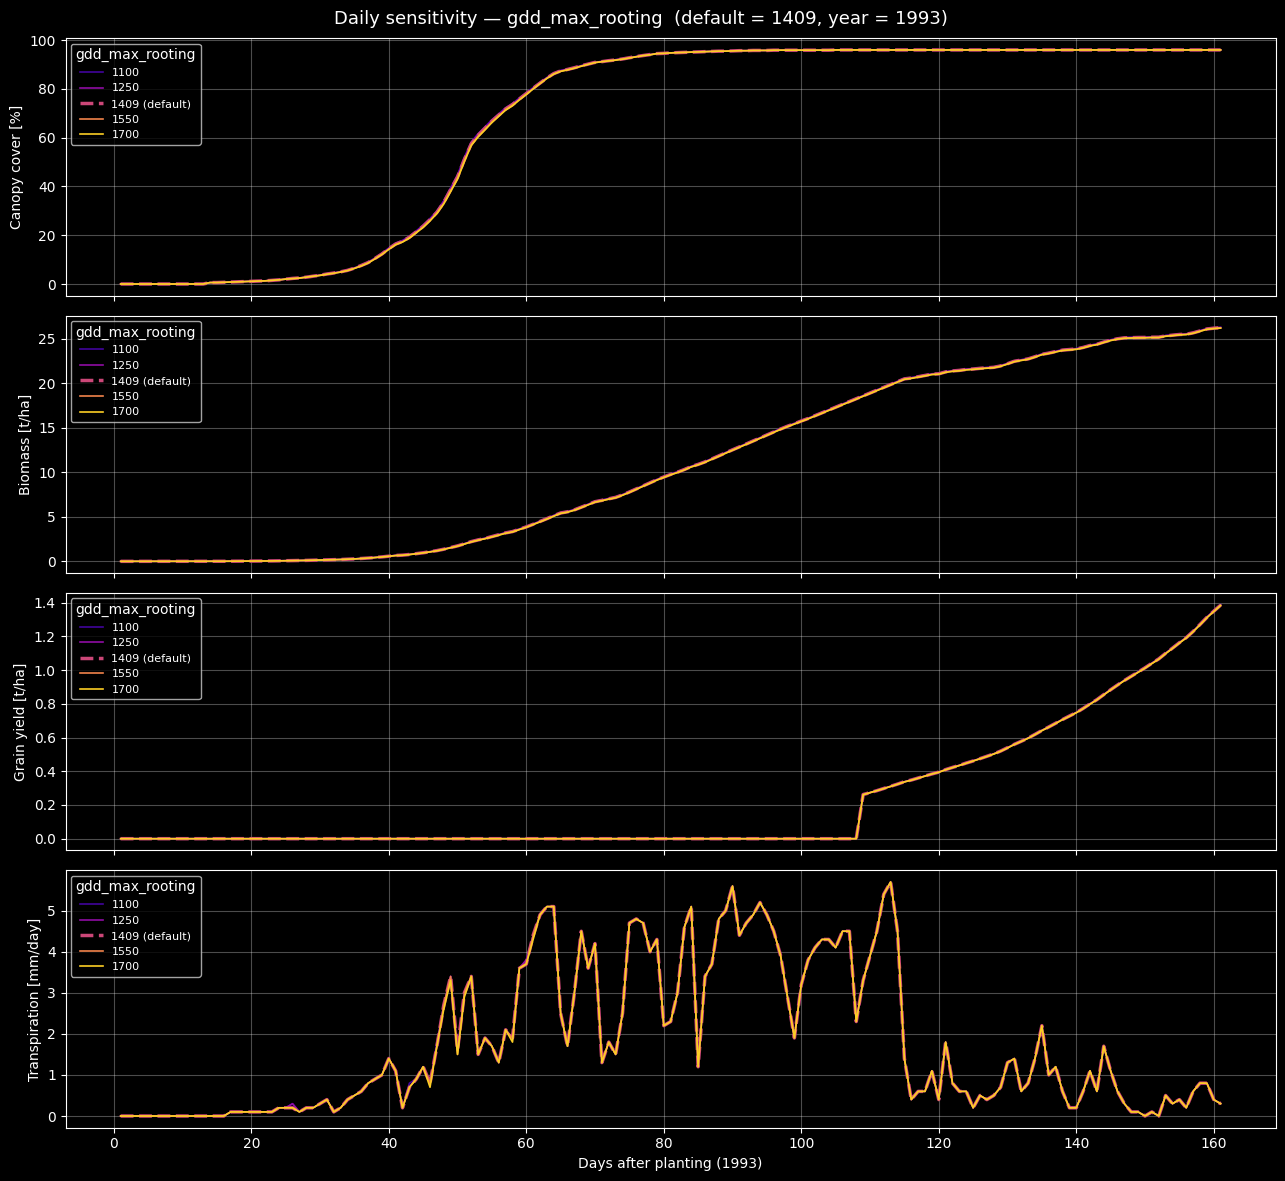

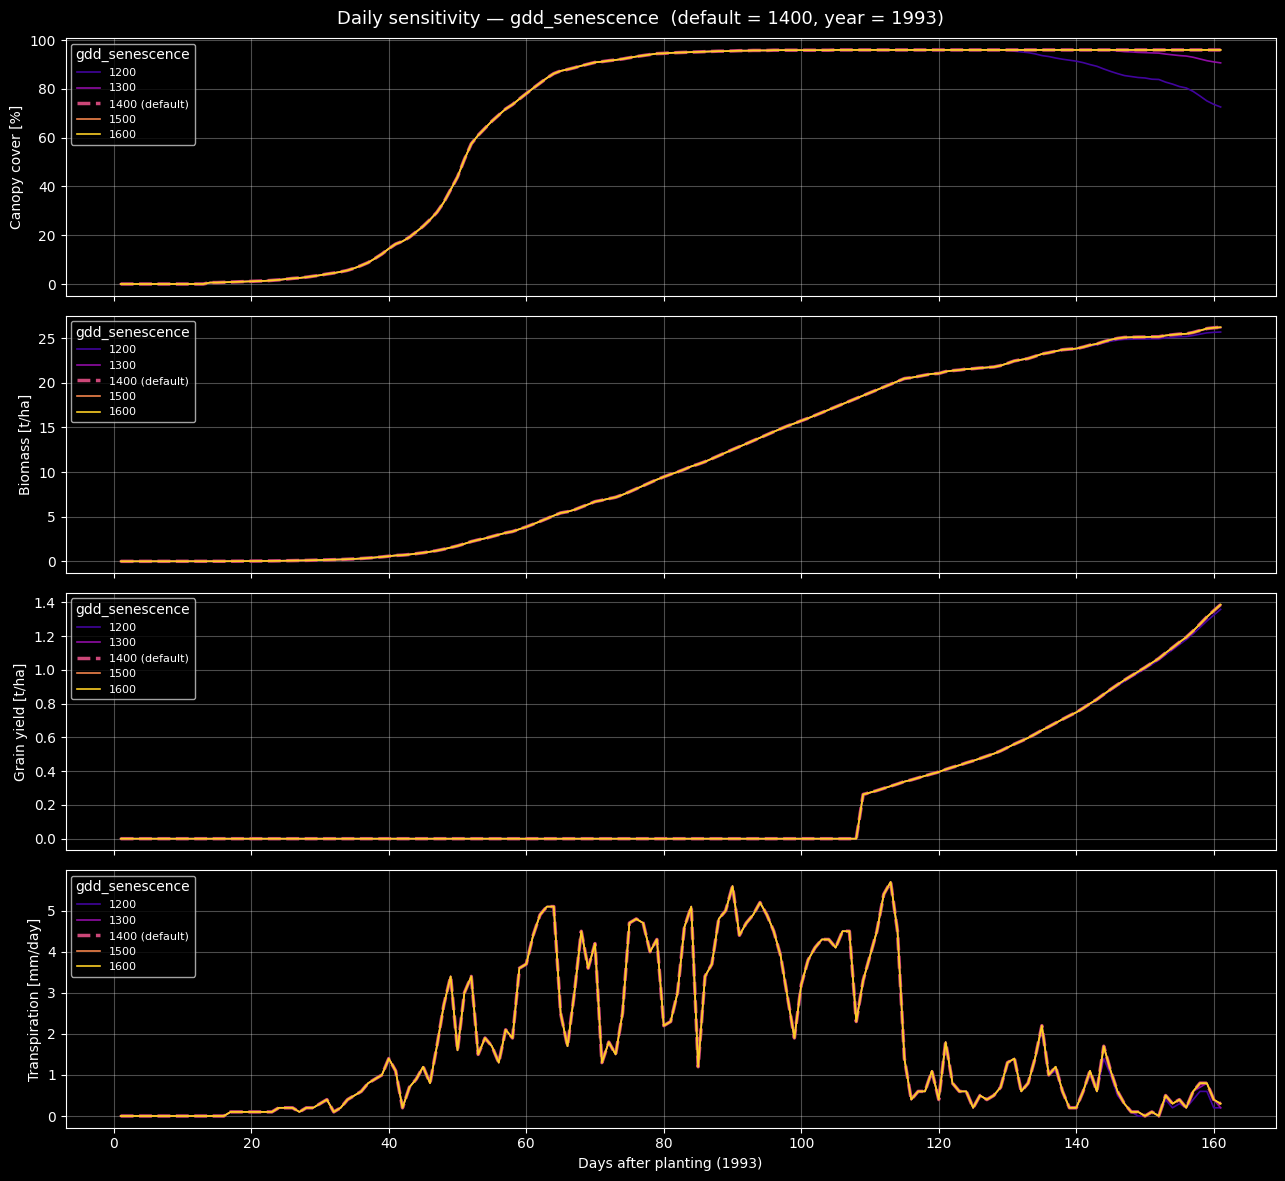

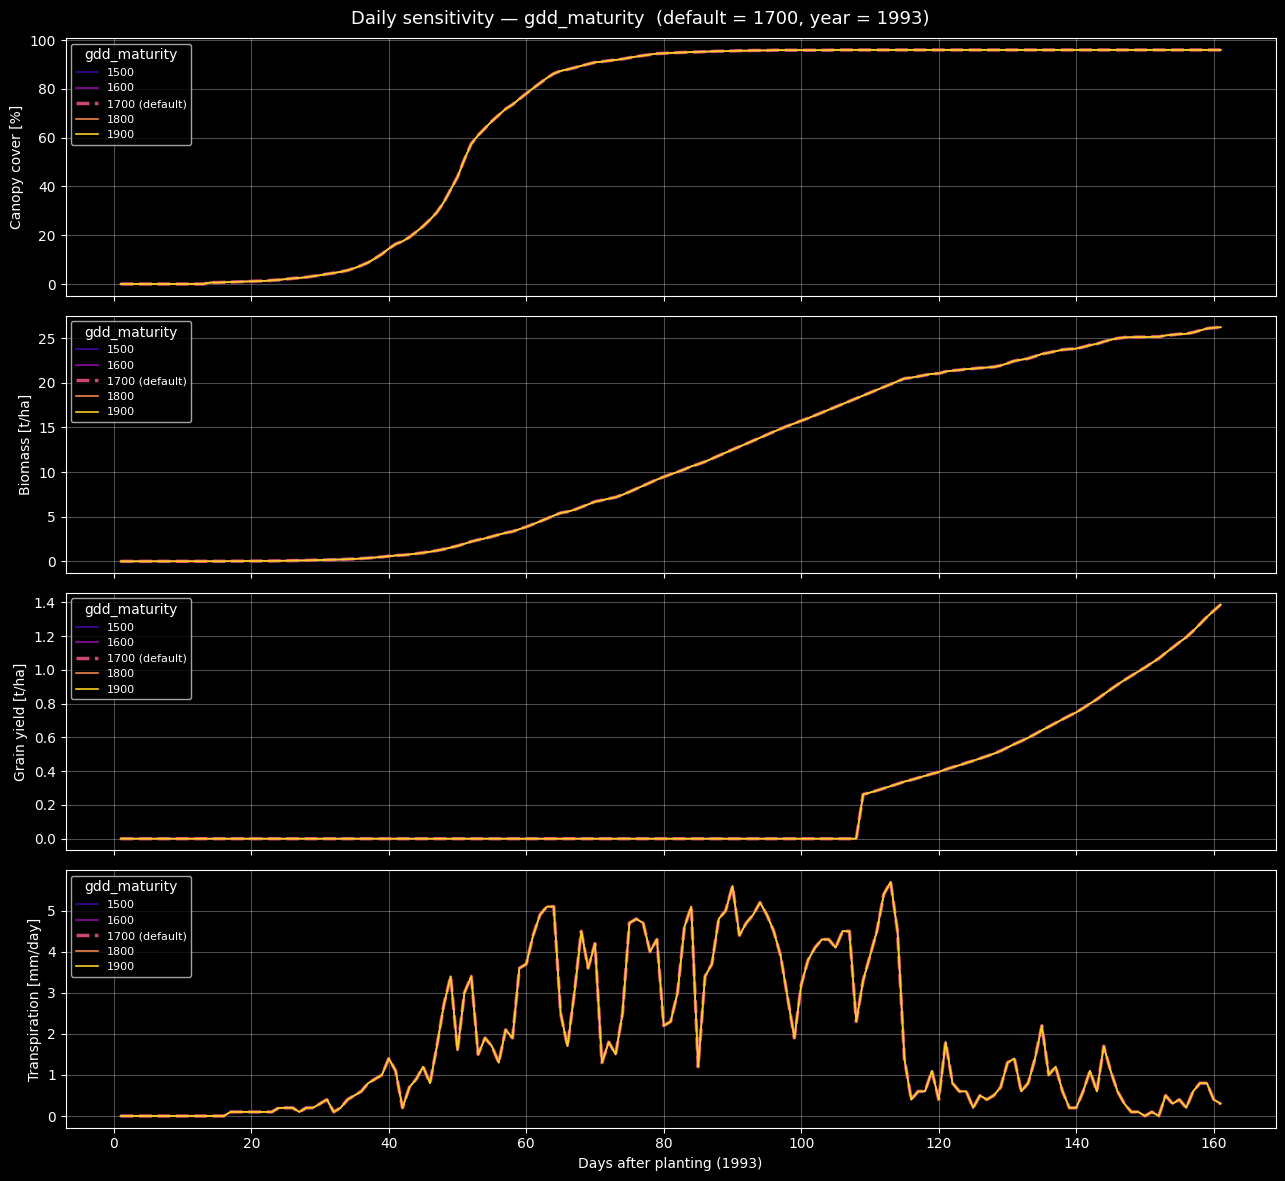

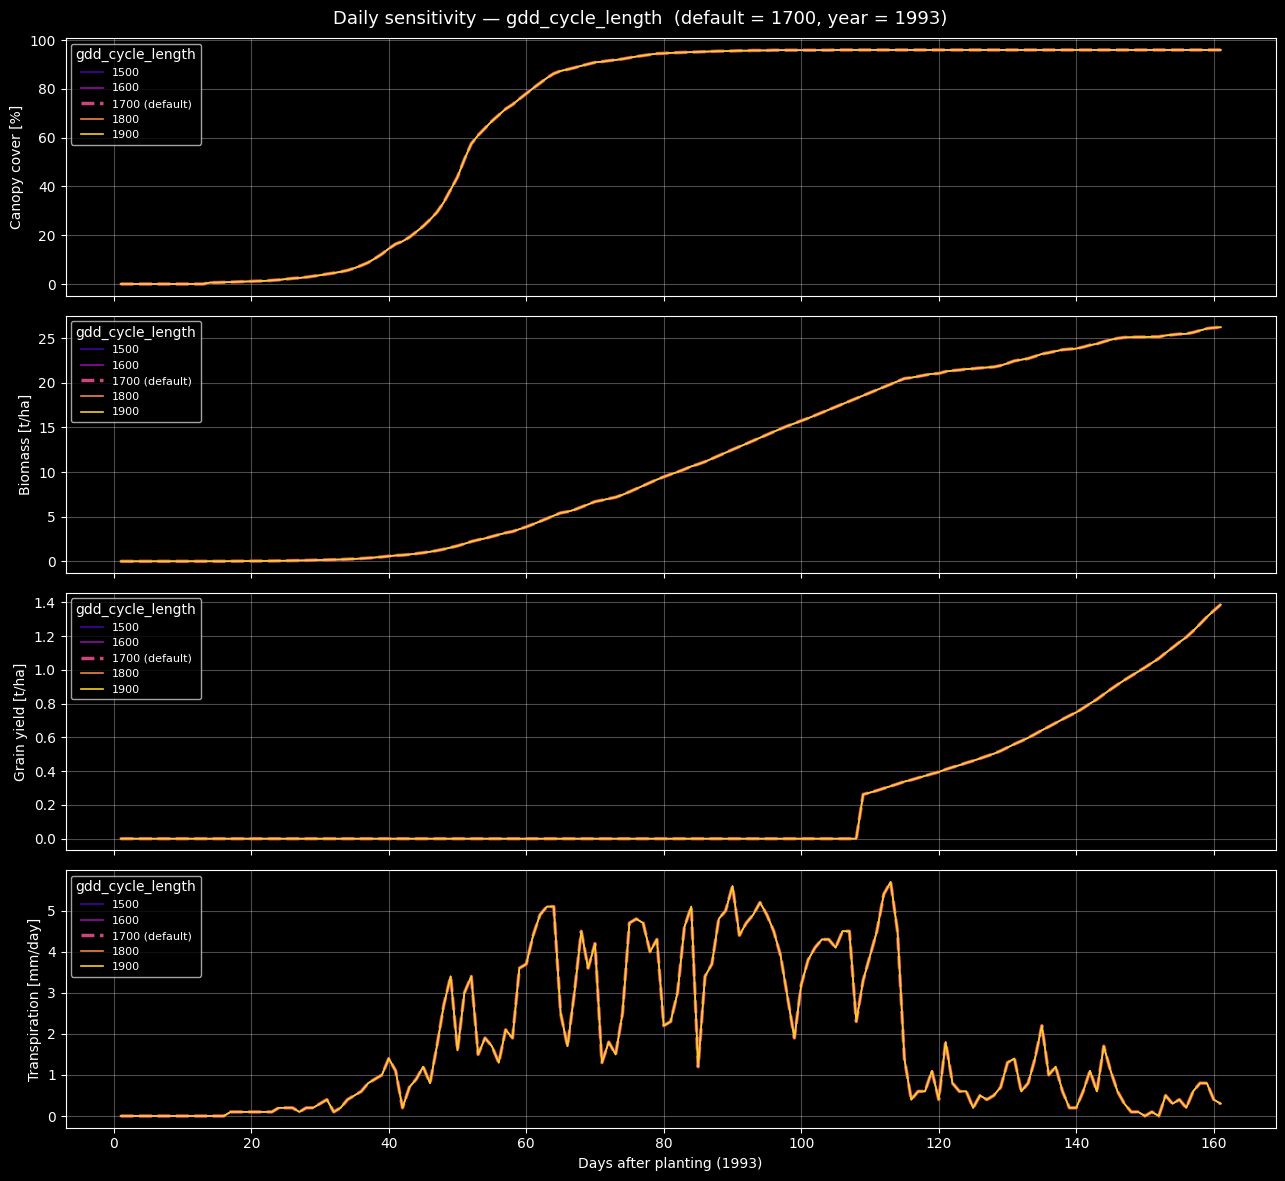

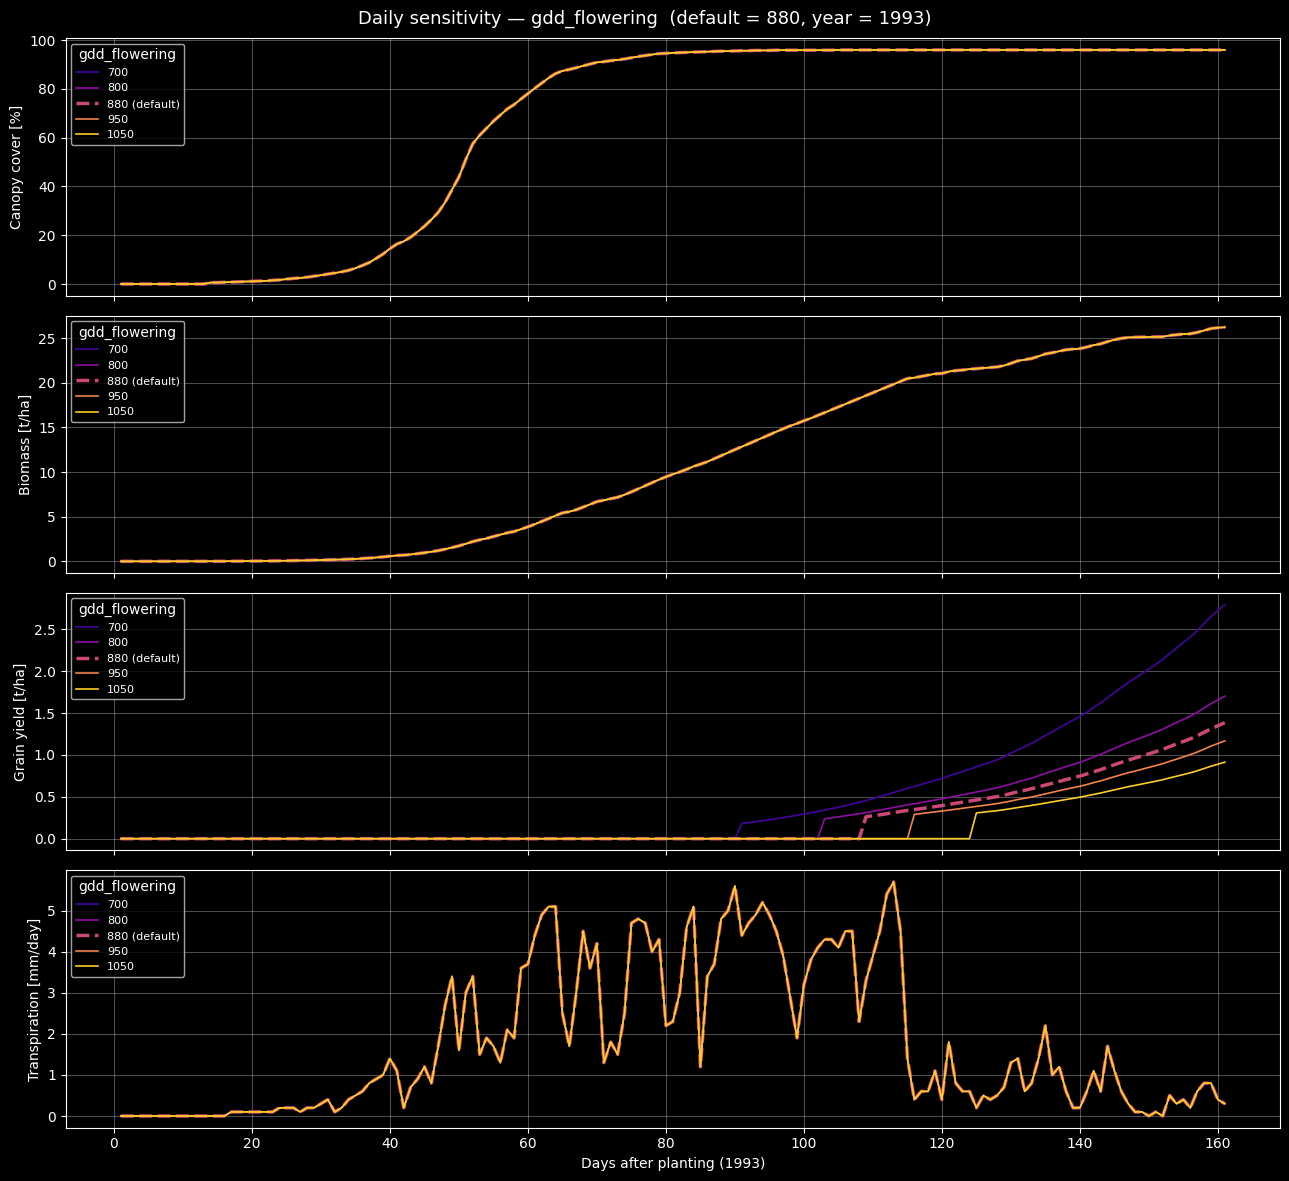

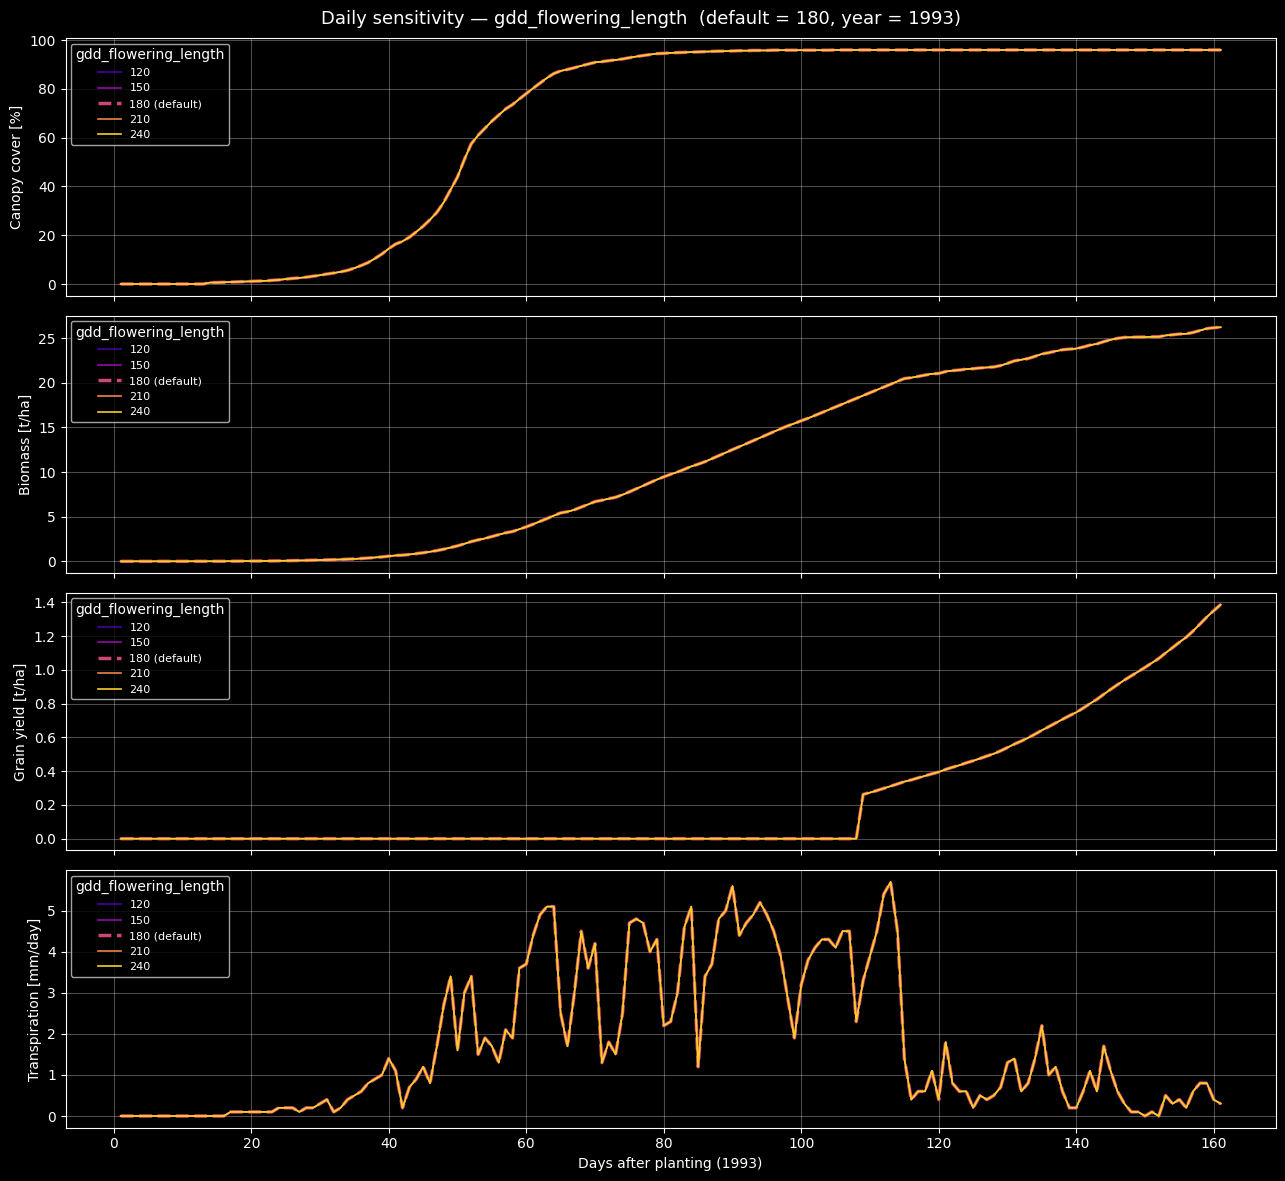

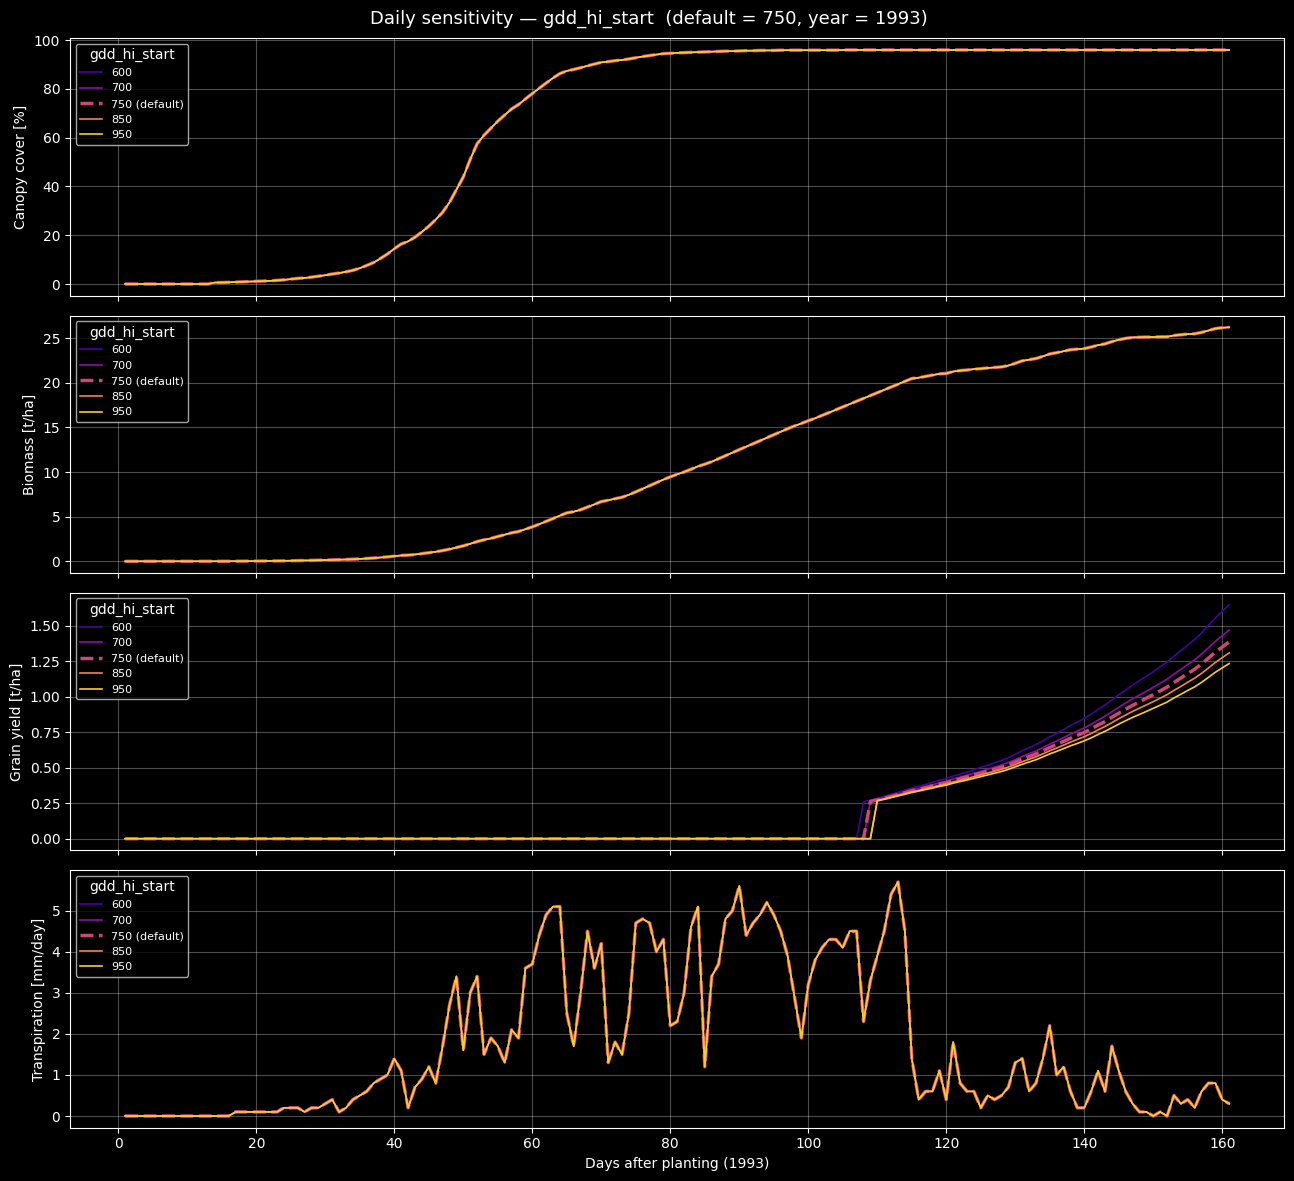

In [22]:
from matplotlib import pyplot as plt

daily_panels = [
    ("CC",      "Canopy cover [%]"),
    ("Biomass", "Biomass [t/ha]"),
    ("Y(dry)",  "Grain yield [t/ha]"),
    ("Tr",      "Transpiration [mm/day]"),
]

for param_name, results_by_value in gdd_daily_results.items():
    values = sorted(results_by_value.keys())
    default_val = jablje_maize_params[param_name]
    colors = cm.plasma(np.linspace(0.1, 0.9, len(values)))

    fig, axes = plt.subplots(len(daily_panels), 1, figsize=(13, 3 * len(daily_panels)), sharex=True)
    fig.suptitle(
        f"Daily sensitivity — {param_name}  (default = {default_val}, year = {year})",
        fontsize=13,
    )

    for ax, (col, ylabel) in zip(axes, daily_panels):
        for val, color in zip(values, colors):
            daily = results_by_value[val]
            lw = 2.5 if val == default_val else 1.2
            ls = "--" if val == default_val else "-"
            ax.plot(
                daily["DAP"].values,
                daily[col].values,
                color=color,
                linewidth=lw,
                linestyle=ls,
                label=f"{val:.4g}" + (" (default)" if val == default_val else ""),
            )
        ax.set_ylabel(ylabel)
        ax.legend(title=param_name, fontsize=8, loc="upper left")
        ax.grid(True, alpha=0.3)

    axes[-1].set_xlabel(f"Days after planting ({year})")
    plt.tight_layout()
    plt.show()